# CLV Modeling with Statistical and Hybrid Approaches


## Modeling Pipeline (Hybrid)

This notebook implements a dual modeling strategy for Customer Lifetime Value (CLV) prediction:
###  Hybrid Model
- Uses both engineered features and `CLV_BGNBD` as inputs.
- Pros: Leverages probabilistic models to capture customer purchase behavior.

.



##  Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Lifetime CLV modeling
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import shap

import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'lifetimes'

##  Load Dataset

In [ ]:
df = pd.read_excel("Supermarket Transactions.xlsx",sheet_name="Data")
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [ ]:
#Check the shape (number of columns and rows) in the dataset
df.shape

(14059, 16)

In [ ]:
#Find out missing values
df.isnull().sum(axis=0)

Transaction           0
Purchase Date         0
Customer ID           0
Gender                0
Marital Status        0
Homeowner             0
Children              0
Annual Income         0
City                  0
State or Province     0
Country               0
Product Family        0
Product Department    0
Product Category      0
Units Sold            0
Revenue               0
dtype: int64

In [ ]:
print(df['Customer ID'].nunique())

5404


##  Preprocessing

In [ ]:
# Drop NA, duplicates, fix types
df = df.drop_duplicates()
df = df.dropna()

# Add total price per transaction
# df['TotalPrice'] = df['Units_Sold'] * df['Unit_Pric']

In [ ]:
def income_avg(income_range):
    try:
        # Remove $ and K and split by dash
        cleaned = income_range.replace('$', '').replace('K', '').replace(',', '').strip()
        numbers = cleaned.split('-')

        # If it's a range, take average
        if len(numbers) == 2:
            return (int(numbers[0]) + int(numbers[1])) / 2 * 1000
        # If it's a single number (e.g., "85"), just return that
        elif len(numbers) == 1:
            return int(numbers[0]) * 1000
    except:
        return np.nan  # If it fails, return NaN

# Apply the fixed function
df['Income_Avg'] = df['Annual Income'].apply(income_avg)


##  Hypothesis Testing

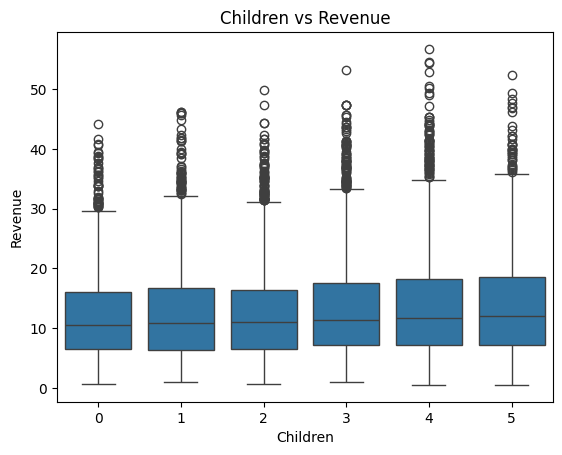

In [ ]:
#bigger family size higher revenue
sns.boxplot(x='Children', y='Revenue', data=df)
plt.title('Children vs Revenue')
plt.show()


Text(0.5, 1.0, 'Income vs Revenue')

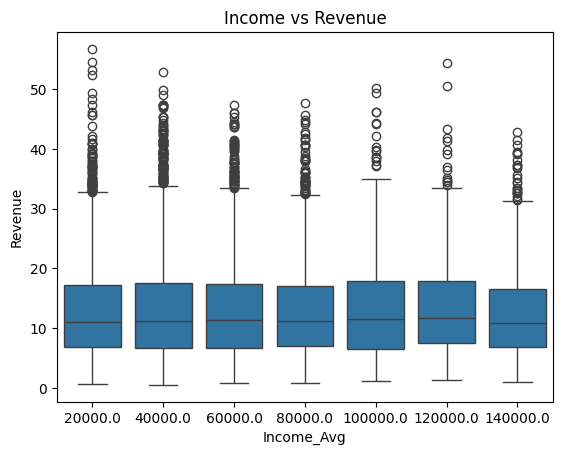

In [ ]:
#higher income higher revenue
sns.boxplot(x='Income_Avg', y='Revenue', data=df)
plt.title('Income vs Revenue')

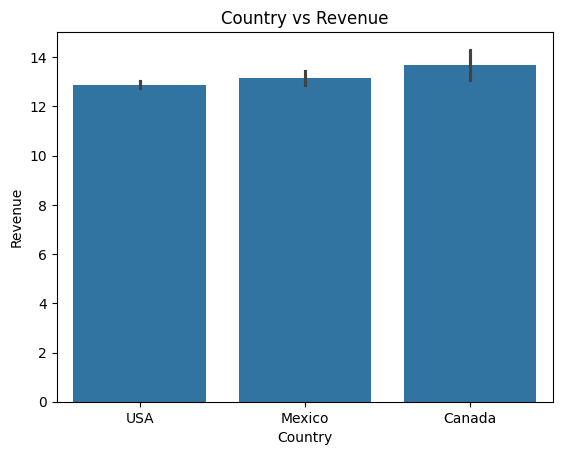

In [ ]:
#revenue distribution for each country
sns.barplot(x='Country', y='Revenue', data=df)  
plt.title('Country vs Revenue')
plt.show()

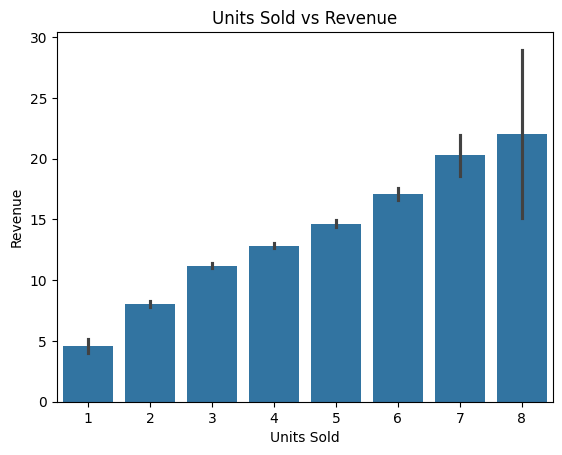

In [ ]:
#units vs revenue
sns.barplot(x="Units Sold",y="Revenue" ,data=df)
plt.title('Units Sold vs Revenue')
plt.show()

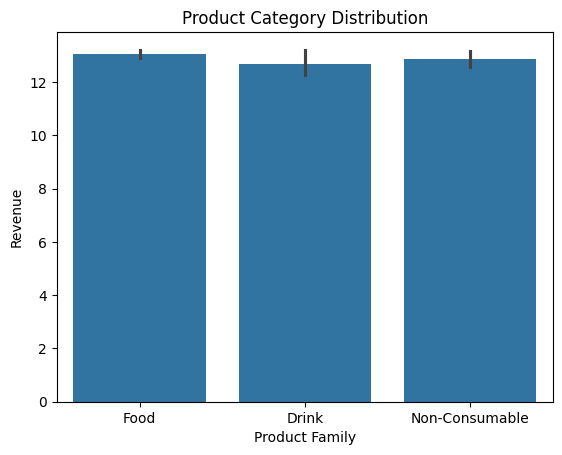

In [ ]:
#product category distribution
sns.barplot(x='Product Family',y="Revenue" ,data=df)
plt.title('Product Category Distribution')
plt.show()

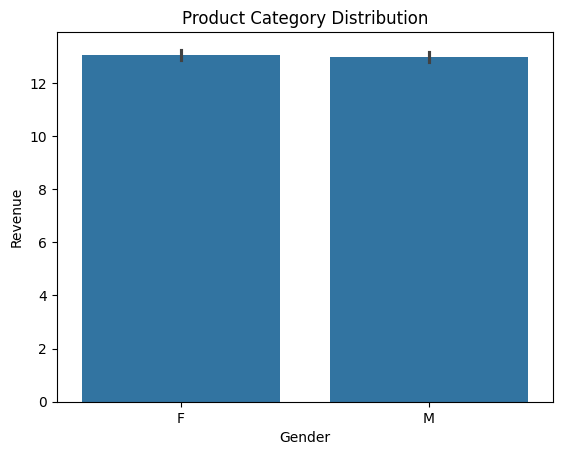

In [ ]:
#plot gender vs revenue
sns.barplot(x="Gender",y="Revenue" ,data=df)
plt.title('Product Category Distribution')
plt.show()

##  RFM + Summary Data

In [ ]:
rfm = summary_data_from_transaction_data(df, 'Customer ID', 'Purchase Date', monetary_value_col='Revenue', observation_period_end=df['Purchase Date'].max())
rfm = rfm.rename(columns={
    'frequency': 'frequency',
    'recency': 'recency',
    'T': 'T',
    'monetary_value': 'monetary_value'
})

count    5404.000000
mean        1.586603
std         2.278194
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        19.000000
Name: frequency, dtype: float64
---------------------------------------
Percentage of customers purchase the item only once: 42.36 %


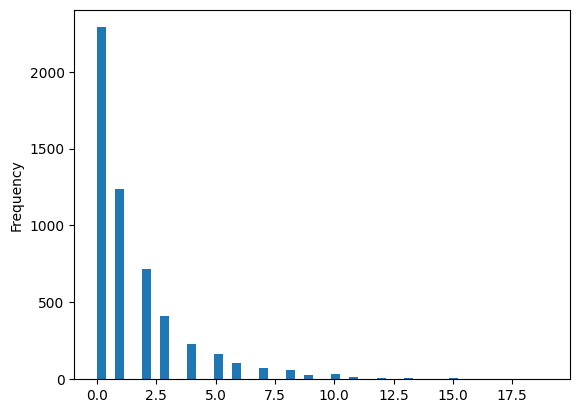

In [ ]:
%matplotlib inline
#Create histogram to find out how many customers purchased item only once.
rfm['frequency'].plot(kind='hist', bins=50)
print(rfm['frequency'].describe())
print("---------------------------------------")
one_time_buyers = round(sum(rfm['frequency'] == 0)/float(len(rfm))*(100),2)
print("Percentage of customers purchase the item only once:", one_time_buyers ,"%")

In [ ]:
#Check if there is correlation between monetary value and frequency in order to use gamma gamma model for CLV calculation.
rfm[['monetary_value', 'frequency']].corr()

,monetary_value,frequency
monetary_value,1.000000,0.480264
frequency,0.480264,1.000000


##  BG/NBD + Gamma-Gamma Modeling

In [ ]:
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(rfm['frequency'], rfm['recency'], rfm['T'])

ggf = GammaGammaFitter(penalizer_coef=0.01)
rfm_monetary = rfm[rfm['monetary_value'] > 0].copy()
ggf.fit(rfm_monetary['frequency'], rfm_monetary['monetary_value'])

rfm_monetary['Expected_Avg_Profit'] = ggf.conditional_expected_average_profit(
    rfm_monetary['frequency'], rfm_monetary['monetary_value']
)

rfm_monetary['CLV_BGNBD'] = ggf.customer_lifetime_value(
    bgf,
    rfm_monetary['frequency'],
    rfm_monetary['recency'],
    rfm_monetary['T'],
    rfm_monetary['monetary_value'],
    time=3,
    discount_rate=0.01,
    freq='D'
)

rfm = rfm.merge(rfm_monetary[['CLV_BGNBD']], left_index=True, right_index=True, how='left')

In [ ]:
bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.732481,0.025177,0.683134,0.781828
alpha,142.871919,6.631328,129.874517,155.869321
a,0.116285,0.014839,0.087201,0.145368
b,0.578164,0.061173,0.458265,0.698062


In [ ]:
ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,3.898271,0.079595,3.742264,4.054278
q,1.559403,0.036305,1.488246,1.630560
v,3.517201,0.080595,3.359235,3.675166


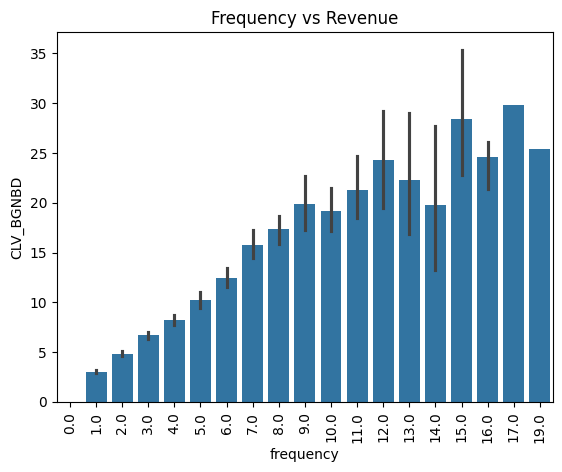

In [ ]:
#Higher the frequency higher the revenue
sns.barplot(x='frequency', y='CLV_BGNBD', data=rfm)
plt.title('Frequency vs Revenue')
plt.xticks(rotation=90)
plt.show()


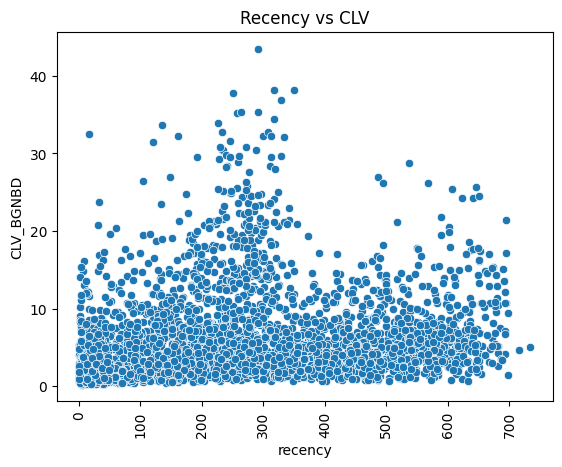

In [ ]:
#More recent higher the CLV 
sns.scatterplot(x='recency', y='CLV_BGNBD', data=rfm)
plt.title('Recency vs CLV')
plt.xticks(rotation=90)
plt.show()

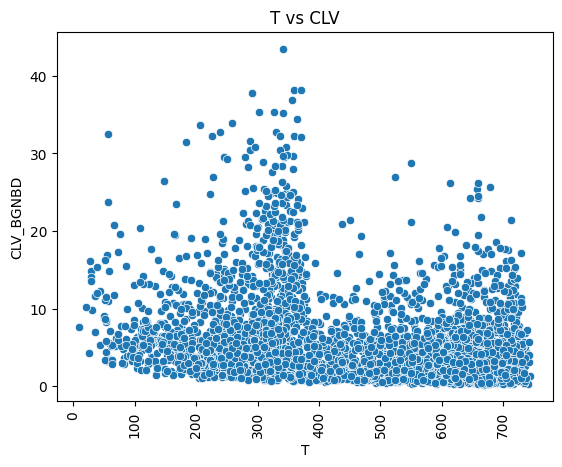

In [ ]:
#Longer the customer stays higher the CLV
sns.scatterplot(x='T', y='CLV_BGNBD', data=rfm)
plt.title('T vs CLV')
plt.xticks(rotation=90)
plt.show()

<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

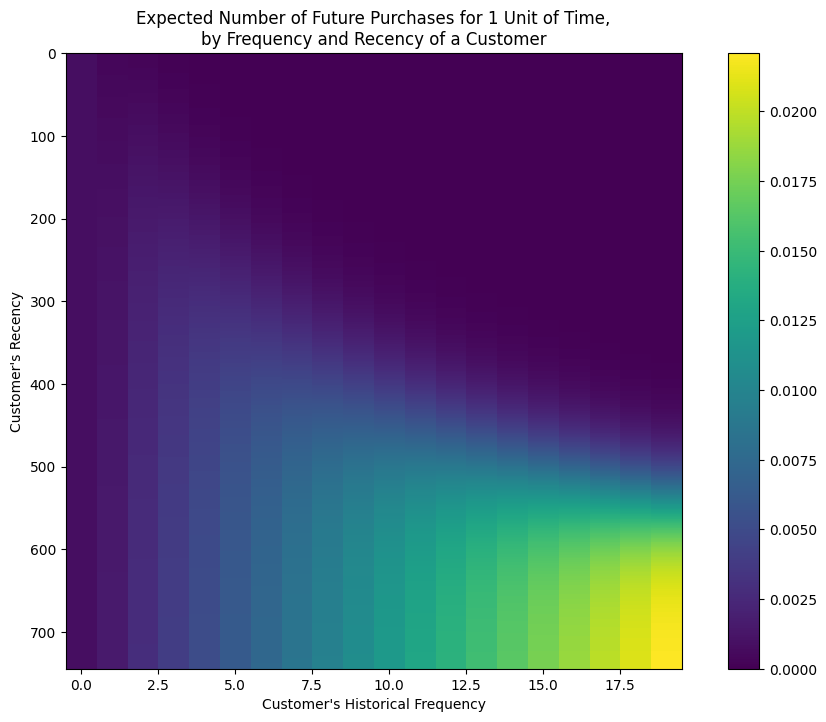

In [ ]:
#Visualizing our frequency/recency matrix
%matplotlib inline
import matplotlib.pyplot as plt
from lifetimes.plotting import plot_frequency_recency_matrix
fig = plt.figure(figsize=(12,8))
plot_frequency_recency_matrix(bgf)

<Axes: title={'center': 'Probability Customer is Alive,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

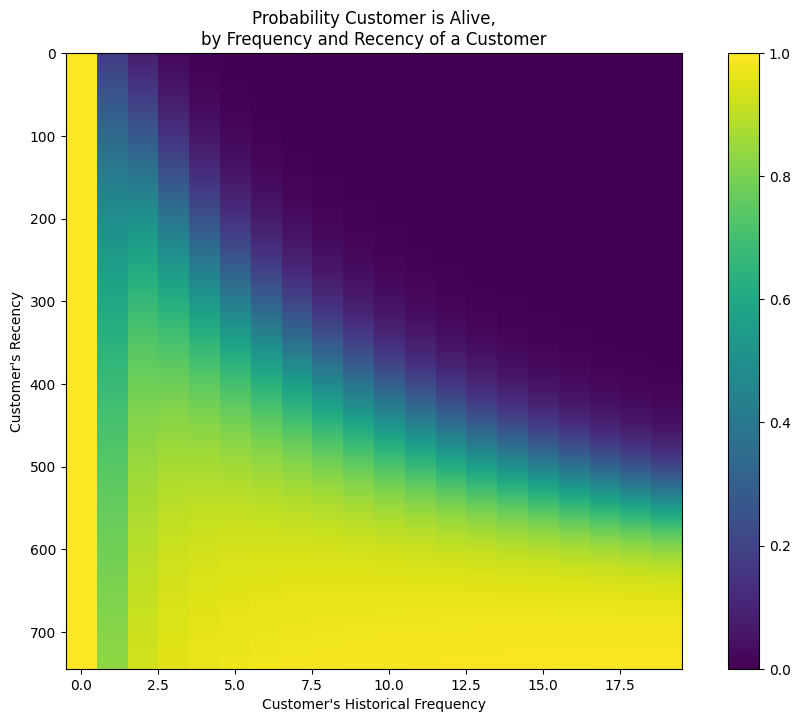

In [ ]:
#predict if the customers are surely alive:
from lifetimes.plotting import plot_probability_alive_matrix
fig = plt.figure(figsize=(12,8))
plot_probability_alive_matrix(bgf)

<Axes: title={'center': 'Frequency of Repeat Transactions'}, xlabel='Number of Calibration Period Transactions', ylabel='Customers'>

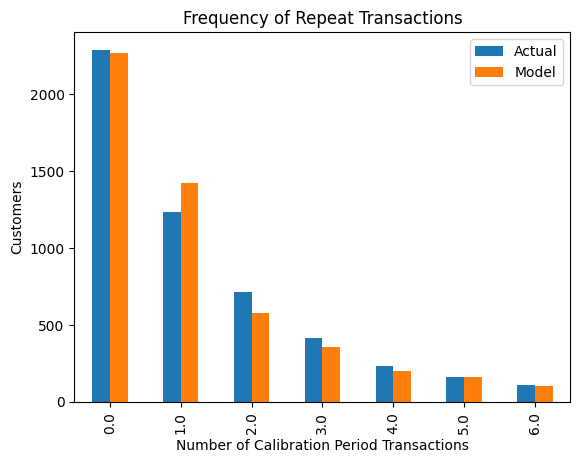

In [ ]:
#Assessing model fit
from lifetimes.plotting import plot_period_transactions
plot_period_transactions(bgf)

##  Feature Engineering

In [ ]:
features = df.groupby('Customer ID').agg({
    'Units Sold': 'sum',
    'Children': 'first',
    'Income_Avg': 'first',
    'Revenue': 'sum'
}).reset_index()

xdata = rfm.reset_index().merge(features, on='Customer ID')

##  Heatmap

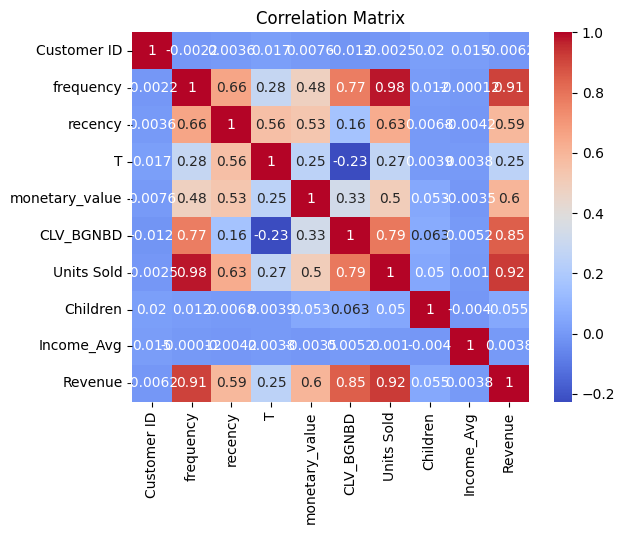

In [ ]:
sns.heatmap(xdata.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

##  ML Models on BGNBD CLV

In [ ]:
# Check for and drop rows with NaN in features or target
ml_data = xdata.drop(columns=['Customer ID'])
ml_data = ml_data.dropna(subset=['CLV_BGNBD'])  # if using hybrid CLV as target

X = ml_data.drop(columns=['CLV_BGNBD'])  # or the relevant CLV column
y = ml_data['CLV_BGNBD']

# Ensure all features are numeric
X = X.select_dtypes(include=[np.number])

# Final split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Linear Regression

Linear Regression Results
Mean Absolute Error: 1.4508366043828385
Mean Squared Error: 5.079328193782127
Root Mean Squared Error: 2.253736496084253
R2 Score: 0.8577693126761278


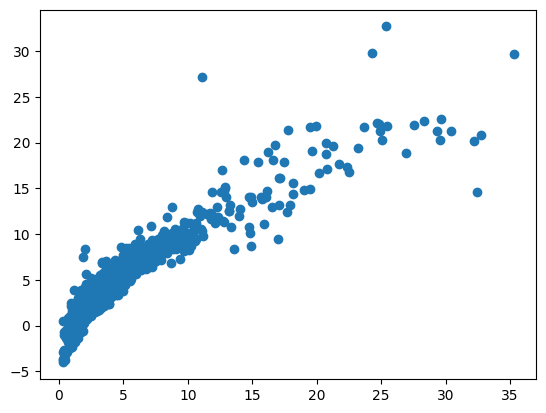

In [ ]:
#linear regression 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  

import numpy as np
# from sklearn.model_selection import train_test_split
linear_model= LinearRegression()

# Replace NaN values with 0
# X_train = np.nan_to_num(X_train, nan=0.0)
# X_test = np.nan_to_num(X_test, nan=0.0)
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)
# Now you can fit the model without errors
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

print("Linear Regression Results")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))
plt.scatter(y_test, y_pred)


### Decision tree

Decision Tree Regression Results
Mean Absolute Error: 1.034307890247075
Mean Squared Error: 4.0708110705266325
Root Mean Squared Error: 2.017625106536552
R2 Score: 0.886009677965797


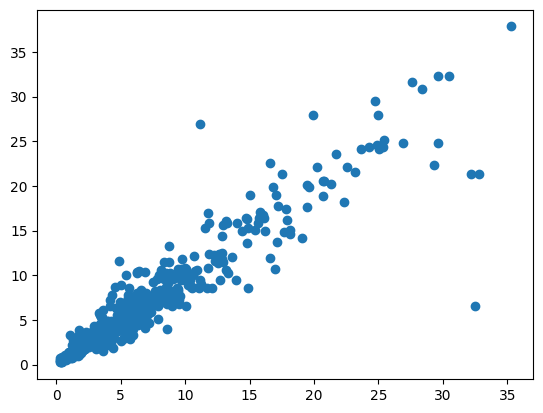

In [ ]:
# decision tree regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)
decision_pred = decision_tree_model.predict(X_test)
print("Decision Tree Regression Results")
print("Mean Absolute Error:", mean_absolute_error(y_test, decision_pred))
print("Mean Squared Error:", mean_squared_error(y_test, decision_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, decision_pred)))
print("R2 Score:", r2_score(y_test, decision_pred))
plt.scatter(y_test, decision_pred)

### XGBoost

In [ ]:
xgb_model = xgb.XGBRegressor(n_estimators=200)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost RMSE:", mean_squared_error(y_test, xgb_preds))
print("XGBoost R²:", r2_score(y_test, xgb_preds))


XGBoost RMSE: 1.4943857514987204
XGBoost R²: 0.9581544045878242


### LightGBM

In [ ]:
lgb_model = lgb.LGBMRegressor(n_estimators=200)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
print("LightGBM RMSE:", mean_squared_error(y_test, lgb_preds))
print("LightGBM R²:", r2_score(y_test, lgb_preds))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1112
[LightGBM] [Info] Number of data points in the train set: 2492, number of used features: 8
[LightGBM] [Info] Start training from score 6.278617
LightGBM RMSE: 1.164549522951218
LightGBM R²: 0.967390435751956


### CatBoost

In [ ]:
cat_model = CatBoostRegressor(verbose=0)
cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)
print("CatBoost RMSE:", mean_squared_error(y_test, cat_preds))
print("CatBoost R²:", r2_score(y_test, cat_preds))

CatBoost RMSE: 0.8359449341381158
CatBoost R²: 0.9765919787004664


##  SHAP for XGBoost

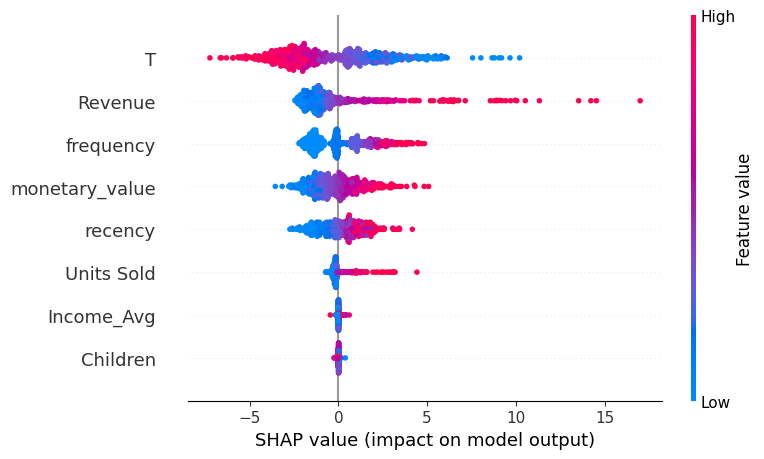

In [ ]:
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
# explainer = shap.Explainer(linear_model, X_train)
# shap_values = explainer(X_test)
# shap.summary_plot(shap_values, X_test)

In [ ]:
# explainer = shap.Explainer(decision_tree_model, X_train)
# shap_values = explainer(X_test)
# shap.summary_plot(shap_values, X_test)

 99%|===================| 614/623 [00:40<00:00]        

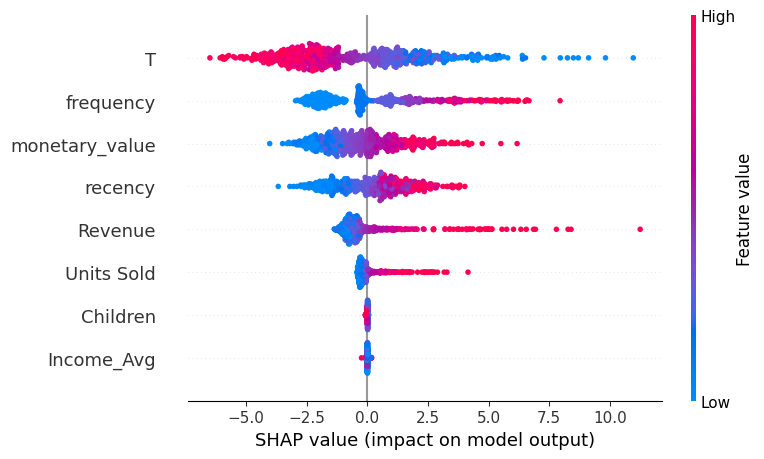

In [ ]:
explainer = shap.Explainer(cat_model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
# explainer = shap.Explainer(lgb_model, X_train)
# shap_values = explainer(X_test)
# shap.summary_plot(shap_values, X_test)

## Feature Pruning

In [ ]:
features = df.groupby('Customer ID').agg({
    'Units Sold': 'sum',
    'Revenue': 'sum'
}).reset_index()

xdata = rfm.reset_index().merge(features, on='Customer ID')

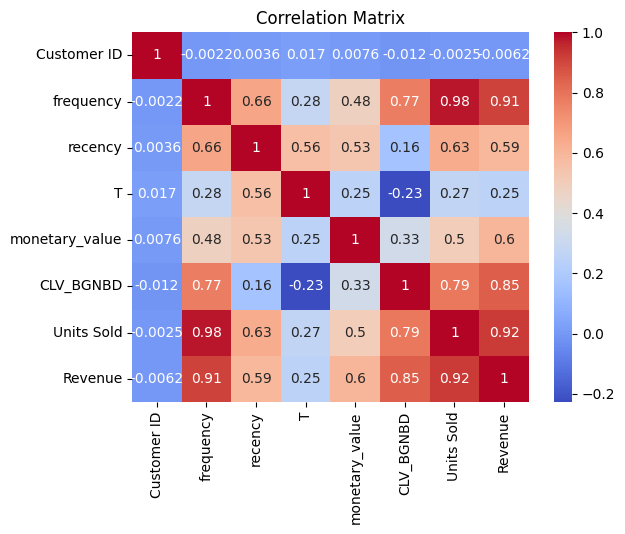

In [ ]:
sns.heatmap(xdata.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Check for and drop rows with NaN in features or target
ml_data = xdata.drop(columns=['Customer ID'])
ml_data = ml_data.dropna(subset=['CLV_BGNBD'])  # if using hybrid CLV as target

X = ml_data.drop(columns=['CLV_BGNBD'])  # or the relevant CLV column
y = ml_data['CLV_BGNBD']

# Ensure all features are numeric
X = X.select_dtypes(include=[np.number])

# Final split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Linear Regression Results
Mean Absolute Error: 1.44433561971184
Mean Squared Error: 5.077768263865563
Root Mean Squared Error: 2.2533903931333255
R2 Score: 0.8578129936307235


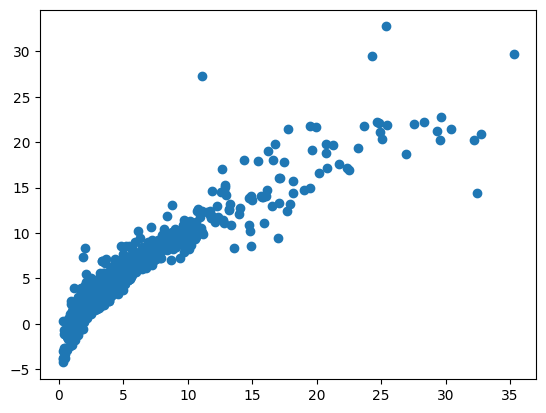

In [ ]:
#linear regression 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  

import numpy as np
# from sklearn.model_selection import train_test_split
linear_model= LinearRegression()

# Replace NaN values with 0
# X_train = np.nan_to_num(X_train, nan=0.0)
# X_test = np.nan_to_num(X_test, nan=0.0)
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)
# Now you can fit the model without errors
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

print("Linear Regression Results")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))
plt.scatter(y_test, y_pred)


Decision Tree Regression Results
Mean Absolute Error: 0.9861740758129942
Mean Squared Error: 3.7921446159691308
Root Mean Squared Error: 1.9473429631087409
R2 Score: 0.893812859775222


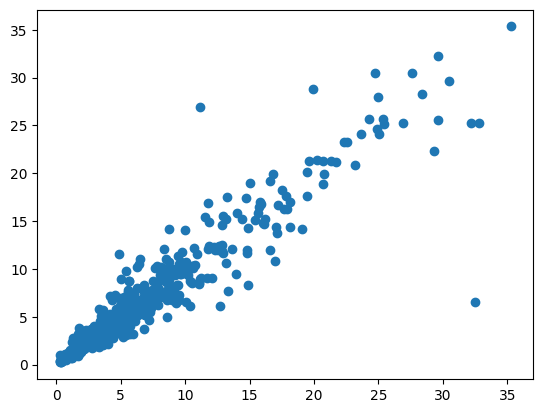

In [ ]:
# decision tree regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)
decision_pred = decision_tree_model.predict(X_test)
print("Decision Tree Regression Results")
print("Mean Absolute Error:", mean_absolute_error(y_test, decision_pred))
print("Mean Squared Error:", mean_squared_error(y_test, decision_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, decision_pred)))
print("R2 Score:", r2_score(y_test, decision_pred))
plt.scatter(y_test, decision_pred)

In [ ]:
xgb_model = xgb.XGBRegressor(n_estimators=200)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost RMSE:", mean_squared_error(y_test, xgb_preds))
print("XGBoost R²:", r2_score(y_test, xgb_preds))


XGBoost RMSE: 1.5175035636958925
XGBoost R²: 0.9575070626180233


In [ ]:
lgb_model = lgb.LGBMRegressor(n_estimators=200)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
print("LightGBM RMSE:", mean_squared_error(y_test, lgb_preds))
print("LightGBM R²:", r2_score(y_test, lgb_preds))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1098
[LightGBM] [Info] Number of data points in the train set: 2492, number of used features: 6
[LightGBM] [Info] Start training from score 6.278617
LightGBM RMSE: 1.15884660541279
LightGBM R²: 0.9675501281069874


In [ ]:
cat_model = CatBoostRegressor(verbose=0)
cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)
print("CatBoost RMSE:", mean_squared_error(y_test, cat_preds))
print("CatBoost R²:", r2_score(y_test, cat_preds))

CatBoost RMSE: 0.7398237480289896
CatBoost R²: 0.9792835516497046


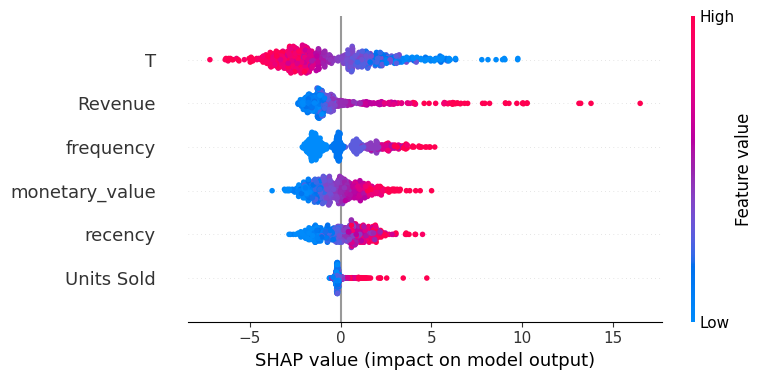

In [ ]:
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

##  Compare All CLVs

In [ ]:
# 1. Create X again for predictions, same preprocessing as during training
X_pred = xdata.drop(columns=['Customer ID', 'CLV_BGNBD'], errors='ignore')
X_pred = X_pred.select_dtypes(include=[np.number])
X_pred = X_pred.dropna()

# # 2. Predict
xgb_preds = xgb_model.predict(X_pred)
lgb_preds = lgb_model.predict(X_pred)
cat_preds = cat_model.predict(X_pred)
y_pred = linear_model.predict(X_pred)
decision_pred = decision_tree_model.predict(X_pred)

# 3. Assign predictions only to rows in xdata that match X_pred
xdata.loc[X_pred.index, 'CLV_Linear'] = y_pred
xdata.loc[X_pred.index, 'CLV_DecisionTree'] = decision_pred
xdata.loc[X_pred.index, 'CLV_XGBoost'] = xgb_preds
xdata.loc[X_pred.index, 'CLV_LightGBM'] = lgb_preds
xdata.loc[X_pred.index, 'CLV_CatBoost'] = cat_preds


##  Save Final CSV

In [ ]:
xdata.to_csv("Final_Clv_All_Models.csv", index=False)
print("Saved: Final_Clv_All_Models.csv")

Saved: Final_Clv_All_Models.csv


In [ ]:
# # Add recency to xdata from RFM table
# xdata = xdata.merge(rfm[['recency']], left_on='Customer ID', right_index=True, how='left')


In [ ]:
# Temporal split based on 80% cutoff in time
cutoff_date = df['Purchase Date'].quantile(0.8)

train_customers = df[df['Purchase Date'] <= cutoff_date]['Customer ID'].unique()
test_customers = df[df['Purchase Date'] > cutoff_date]['Customer ID'].unique()

X_train = xdata[xdata['Customer ID'].isin(train_customers)].drop(columns=['Customer ID', 'CLV_BGNBD'], errors='ignore')
y_train = xdata[xdata['Customer ID'].isin(train_customers)]['CLV_BGNBD']

X_test = xdata[xdata['Customer ID'].isin(test_customers)].drop(columns=['Customer ID', 'CLV_BGNBD'], errors='ignore')
y_test = xdata[xdata['Customer ID'].isin(test_customers)]['CLV_BGNBD']


In [ ]:
from sklearn.cluster import KMeans

# Fill missing CLV with 0 before clustering
clv_for_cluster = xdata[['CLV_BGNBD']].fillna(0)

# 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
xdata['Segment'] = kmeans.fit_predict(clv_for_cluster)

# Map cluster numbers to meaningful names
cluster_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
xdata['Segment'] = xdata['Segment'].map(cluster_mapping)


In [ ]:
# Predict expected orders in next 90 days
rfm['expected_orders_90D'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,  # future time window in days
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)


In [ ]:
# Expected average order value
rfm['expected_aov'] = ggf.conditional_expected_average_profit(
    rfm['frequency'],
    rfm['monetary_value']
)
rfm['expected_revenue_90D'] = rfm['expected_orders_90D'] * rfm['expected_aov']

Correlation between models and probabilistic CLV:
                   Customer ID  CLV_XGBoost  CLV_LightGBM  CLV_CatBoost  \
Customer ID           1.000000    -0.005649     -0.005713     -0.006510   
CLV_XGBoost          -0.005649     1.000000      0.997302      0.997909   
CLV_LightGBM         -0.005713     0.997302      1.000000      0.998125   
CLV_CatBoost         -0.006510     0.997909      0.998125      1.000000   
CLV_Probabilistic    -0.012367     0.954804      0.951975      0.952332   

                   CLV_Probabilistic  
Customer ID                -0.012367  
CLV_XGBoost                 0.954804  
CLV_LightGBM                0.951975  
CLV_CatBoost                0.952332  
CLV_Probabilistic           1.000000  


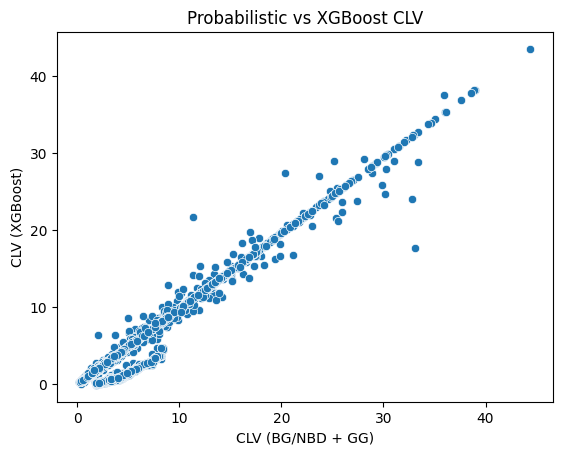

In [ ]:
# Extract predictions from previous ML models if not already stored
comparison = xdata[['Customer ID', 'CLV_XGBoost', 'CLV_LightGBM', 'CLV_CatBoost']].copy()

# Merge with probabilistic CLV
comparison = comparison.merge(rfm[['expected_revenue_90D']], left_on='Customer ID', right_index=True)

# Rename for clarity
comparison = comparison.rename(columns={
    'expected_revenue_90D': 'CLV_Probabilistic'
})

# Correlation matrix
print("Correlation between models and probabilistic CLV:")
print(comparison.corr())

# Plot for XGBoost
sns.scatterplot(data=comparison, x='CLV_Probabilistic', y='CLV_XGBoost')
plt.title("Probabilistic vs XGBoost CLV")
plt.xlabel("CLV (BG/NBD + GG)")
plt.ylabel("CLV (XGBoost)")
plt.show()


In [ ]:
# Merge all into a final table
final = xdata.merge(
    rfm[['expected_orders_90D', 'expected_aov', 'expected_revenue_90D']],
    left_on='Customer ID',
    right_index=True,
    how='left'
)

# Save final comparison table
final.to_csv("CLV_Full_Comparison.csv", index=False)
print("Saved: CLV_Full_Comparison.csv")


Saved: CLV_Full_Comparison.csv


In [ ]:
final.columns

Index(['Customer ID', 'frequency', 'recency', 'T', 'monetary_value',
       'CLV_BGNBD', 'Units Sold', 'Revenue', 'CLV_Linear', 'CLV_DecisionTree',
       'CLV_XGBoost', 'CLV_LightGBM', 'CLV_CatBoost', 'Segment',
       'expected_orders_90D', 'expected_aov', 'expected_revenue_90D'],
      dtype='object')

 Error Summary Statistics:


,Abs_Error_XGBoost,Pct_Error_XGBoost,Abs_Error_LightGBM,Pct_Error_LightGBM,Abs_Error_CatBoost,Pct_Error_CatBoost
count,5324.000000,5324.000000,5324.000000,5324.000000,5324.000000,5324.000000
mean,1.334231,34.423269,1.382788,35.771960,1.377483,35.498692
std,1.475876,37.653439,1.501173,38.009306,1.517194,37.750773
min,0.000092,0.003911,0.000014,0.000837,0.000058,0.000850
25%,0.090017,1.974987,0.112254,2.723852,0.106367,2.561613
50%,0.323581,5.064997,0.404129,7.784350,0.408278,7.130004
75%,2.571162,77.466316,2.682589,76.702891,2.587351,80.735272
max,15.415429,215.717298,13.018429,195.856753,12.085338,106.524152


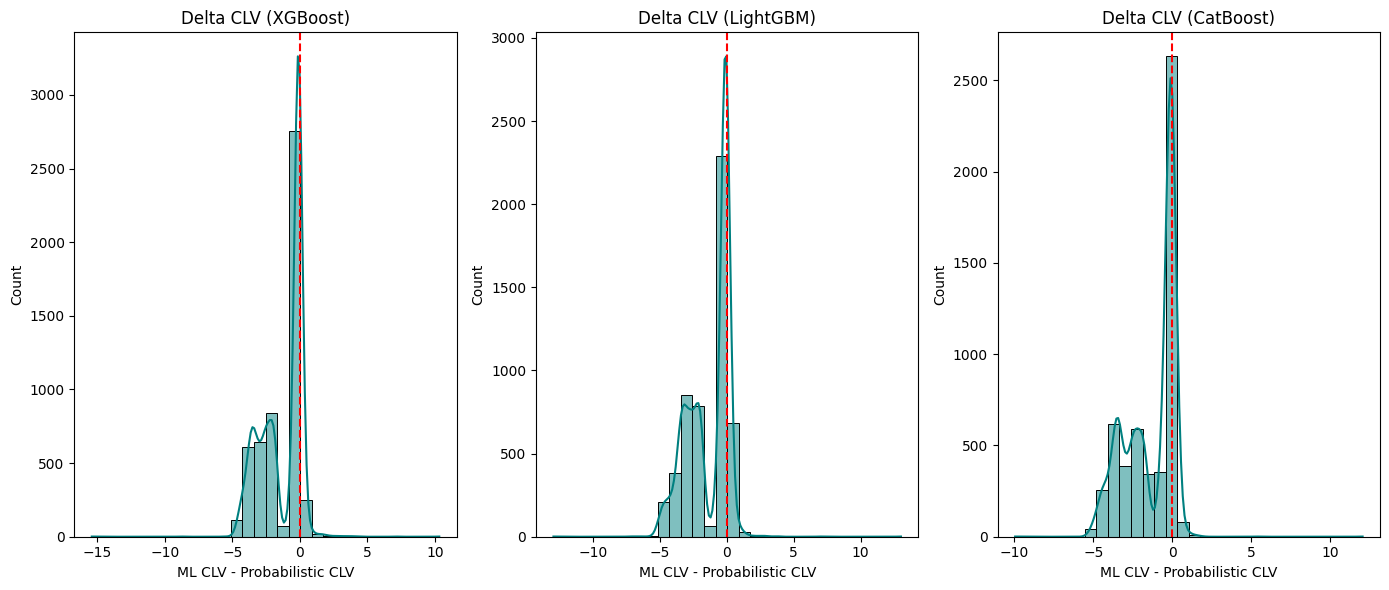

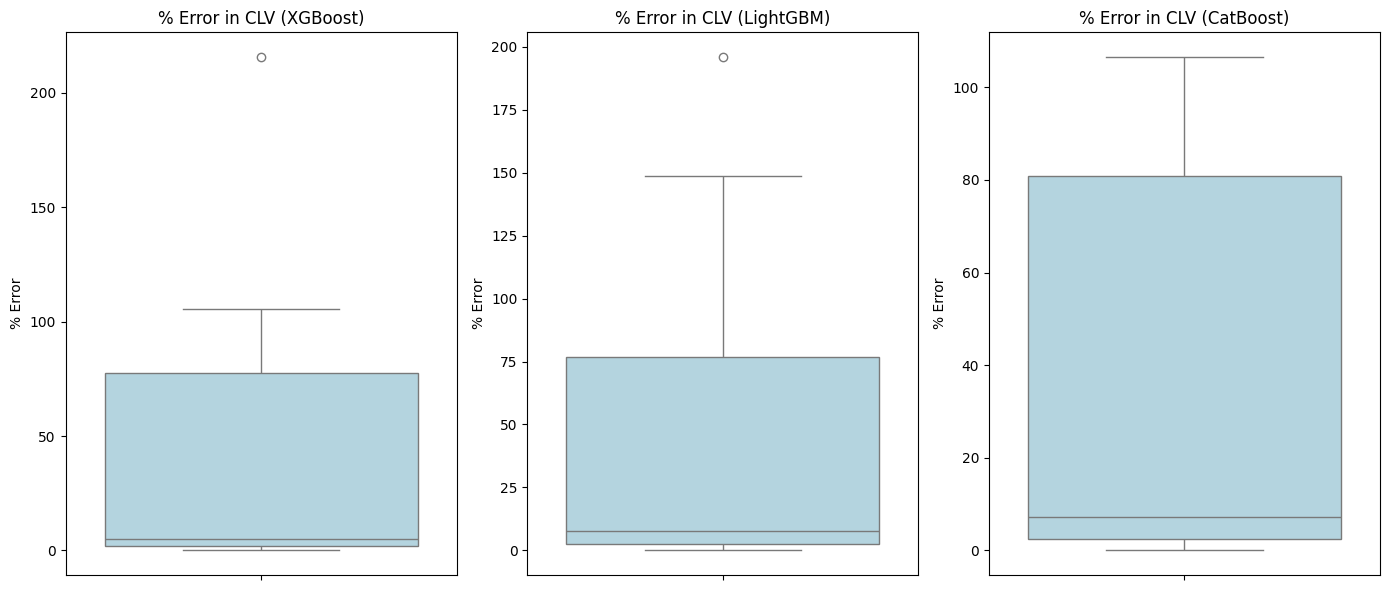

In [ ]:
#  Step 1: Create delta (error) columns
comparison['Delta_XGBoost'] = comparison['CLV_XGBoost'] - comparison['CLV_Probabilistic']
comparison['Delta_LightGBM'] = comparison['CLV_LightGBM'] - comparison['CLV_Probabilistic']
comparison['Delta_CatBoost'] = comparison['CLV_CatBoost'] - comparison['CLV_Probabilistic']

#  Step 2: Calculate absolute error and percentage error
for model in ['XGBoost', 'LightGBM', 'CatBoost']:
    comparison[f'Abs_Error_{model}'] = comparison[f'Delta_{model}'].abs()
    comparison[f'Pct_Error_{model}'] = comparison[f'Abs_Error_{model}'] / (comparison['CLV_Probabilistic'] + 1e-8) * 100

# Step 3: Summary statistics
summary = comparison[[col for col in comparison.columns if 'Error' in col]].describe()
print(" Error Summary Statistics:")
display(summary)

#  Step 4: Visualize delta distributions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
for i, model in enumerate(['XGBoost', 'LightGBM', 'CatBoost']):
    plt.subplot(1, 3, i+1)
    sns.histplot(comparison[f'Delta_{model}'], kde=True, bins=30, color='teal')
    plt.title(f'Delta CLV ({model})')
    plt.xlabel('ML CLV - Probabilistic CLV')
    plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

#  Step 5: Visualize percentage error
plt.figure(figsize=(14, 6))
for i, model in enumerate(['XGBoost', 'LightGBM', 'CatBoost']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=comparison[f'Pct_Error_{model}'], color='lightblue')
    plt.title(f'% Error in CLV ({model})')
    plt.ylabel('% Error')

plt.tight_layout()
plt.show()


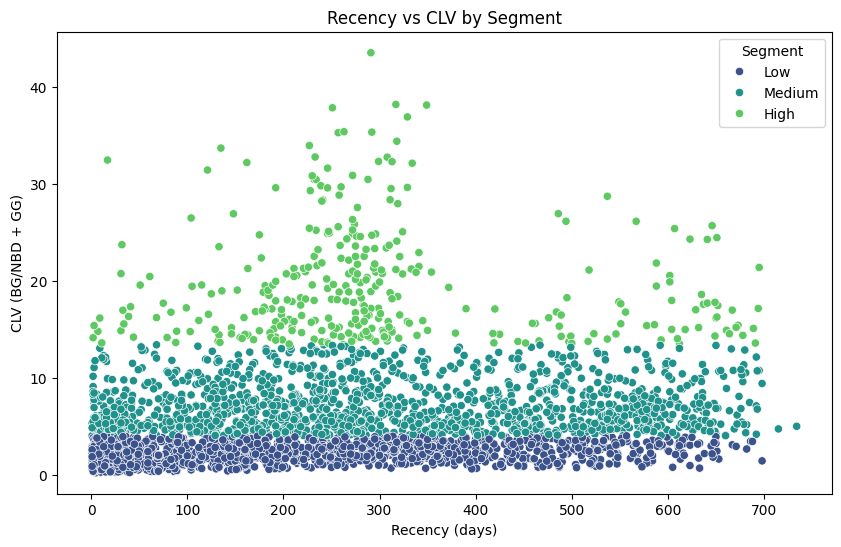

In [ ]:
#scatter plot for recency vs segment
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final, x='recency', y='CLV_BGNBD', hue='Segment', palette='viridis')
plt.title('Recency vs CLV by Segment')
plt.xlabel('Recency (days)')
plt.ylabel('CLV (BG/NBD + GG)')
plt.legend(title='Segment')
plt.show()

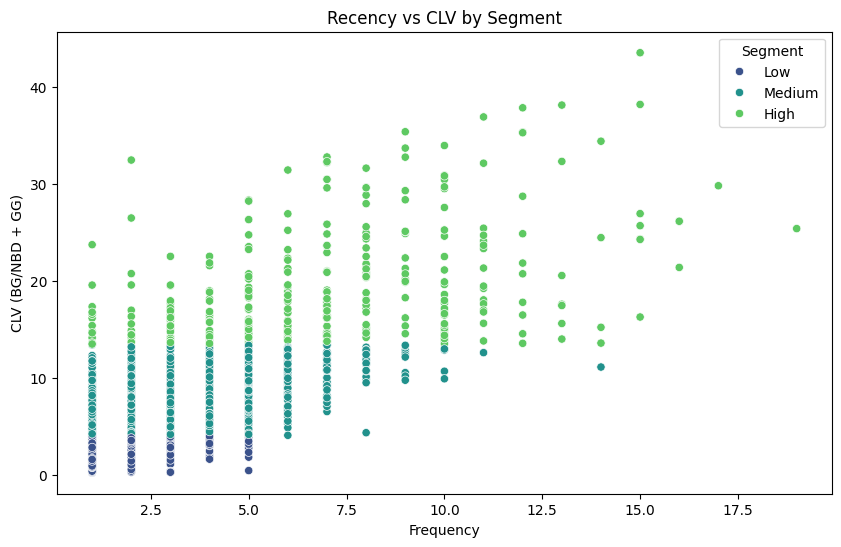

In [ ]:
#scatter plot for recency vs segment
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final, x='frequency', y='CLV_BGNBD', hue='Segment', palette='viridis')
plt.title('Recency vs CLV by Segment')
plt.xlabel('Frequency')
plt.ylabel('CLV (BG/NBD + GG)')
plt.legend(title='Segment')
plt.show()

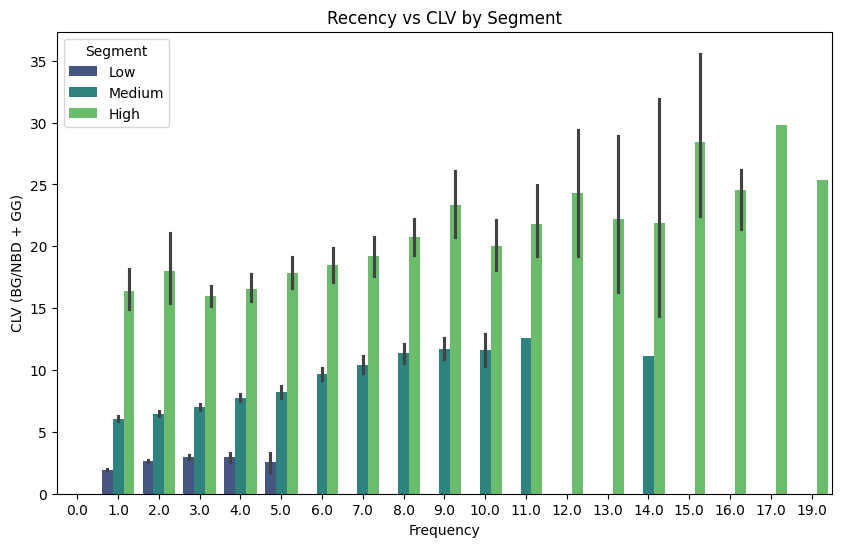

In [ ]:
#scatter plot for recency vs segment
plt.figure(figsize=(10, 6))
sns.barplot(data=final, x='frequency', y='CLV_BGNBD', hue='Segment', palette='viridis')
plt.title('Recency vs CLV by Segment')
plt.xlabel('Frequency')
plt.ylabel('CLV (BG/NBD + GG)')
plt.legend(title='Segment')
plt.show()

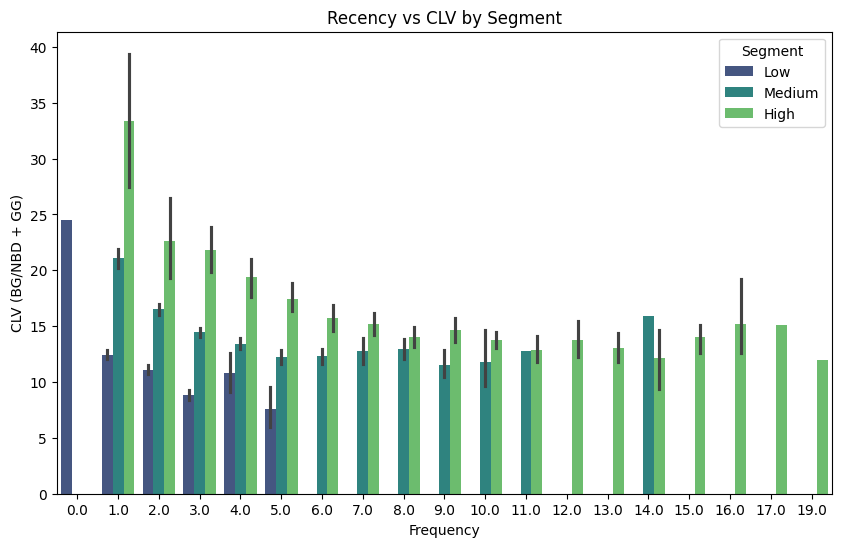

In [ ]:
#scatter plot for recency vs segment
plt.figure(figsize=(10, 6))
sns.barplot(data=final, x='frequency', y='expected_aov', hue='Segment', palette='viridis')
plt.title('Recency vs CLV by Segment')
plt.xlabel('Frequency')
plt.ylabel('CLV (BG/NBD + GG)')
plt.legend(title='Segment')
plt.show()